# Firing rate, correlation

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

# Formatting

In [2]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 9,             # X tick label size (8-12)
    "ytick.labelsize": 9,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    "figure.figsize": (16, 6),       # Figsize
    # "figure.figsize": (8, 6)       # Figsize
        # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [6]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 20,             # Axis title size
    "axes.labelsize": 22,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 16,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
        # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

## Color map

In [3]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# Path

In [4]:
import os

figure_folder = 'omit_zero/figures_omitzero'


# Firing rate distributions

## Files

To save what I want to continue working on, I make csv files containing all spikes across the 5 seconds after learning, for each dynamic/simulation/pqif. Now I can use the csv to analyze it instead of regenerating it each time I run it.

In [ ]:
# ========== Firing rate distributions ==========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
import random
from brokenaxes import brokenaxes
import sys

########## Initialization of lists of values needed ##########


# Simulation variables
simulation_number = [i for i in range(1, 5)]  # 1, 5 for osc;  9, 13 for seq
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
names_homogenous = ["LIF", "QIF"]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]

# seed_number = [i for i in range(0, 50)]  # If only one seed, set to (0, 1)
dynamics = ['oscillations', 'sequences']


########## Time variables ##########
ms_per_file = 1000  # miliseconds
sec_after_learning = 5  # seconds after learning is from (inclusive) 11 to 16 (exclusive)
total_ms = ms_per_file * sec_after_learning  # 1000 * 5 = 5000 ms in total
T_seconds = total_ms / 1000  # To get in seconds so we get Hz


########## Make dataframe ##########

# results = []  # Store all results
# dicts = []  # store all dicts
# across_seeds = []

neurons = [i for i in range(0, 200)]

rows = []
dfs_with_params = []

seed_number = [random.randint(1, 49)]
print(f"Used seed {seed_number}")
# 2 is used for the other figures now so we use 2 now

base = "firing_rate_files"

for dyn in dynamics:


    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)] # Correct simulaton numbers from dynamics

    for seed in seed_number:
        for sim, vr, f in zip(simulation_number, vr_number, slope):

            for pq, name in zip(pqif_homogenous, names_homogenous):


                # spikes_df.to_csv(f'spikes_after_learning/{dyn}_sim_{sim}_pqif_{pq}.csv', index=False, header=False)  # Now contains all spikes after learning for one dyn/sim/pqif
                # spikes_df = pd.to_csv(f'spikes_after_learning/{dyn}_sim_{sim}_pqif_{pq}.csv', index=False, header=False)  # Now contains all spikes after learning for one dyn/sim/pqif
                


                ########## Firing rate for neuron i: Sum across column i (that neuron's spikes over 5 sec), divide by total time ##########

                

                spike_counts = spikes_df.sum(axis=0)  # returns a Pandas series indexed by column number containing spike sum for neuron i

                spikes_per_neuron = spike_counts.to_numpy()  # numpy array shape (neurons, )

                firing_rate_hz = spikes_per_neuron / T_seconds  # elementwise division, gives each neurons firing rate


                # print(f"{dyn.upper()}\nsim {sim}, pq {pq}\nMax firing rate: {firing_rate_hz.max()}\nMin firing rate: {firing_rate_hz.min()}\nMean firing rate: {firing_rate_hz.mean()}")

                corr_list.append(firing_rate_hz)  # Append LIF and QIF in current simulation
            

            x, y = corr_list  # Take arrays for LIF and QIF, assign to variables
            corr = np.corrcoef(x,y)[0, 1]  # Compute Pearson correlation across neurons 1,...N

            # print(f"Correlation in sim {sim}: {np.corrcoef(x,y)[0, 1]}")

            stats_firing_rate = [dyn, sim, vr, f, seed, corr]
            rows.append(stats_firing_rate)

# Make csv with parameters

print("finished")

# columns = ['dyn', 'sim', 'vr', 'f', 'seed', 'correlation']
# stats = pd.DataFrame(rows, columns=columns)
# stats_copy = stats.copy()

# display(stats_copy)

Used seed [2]
finished


In [6]:
spikes_df = pd.read_csv('spikes_after_learning/oscillations_sim_1_pqif_0.csv', header=None)
spikes_df

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Old version

Generates each time

Used seed [48]


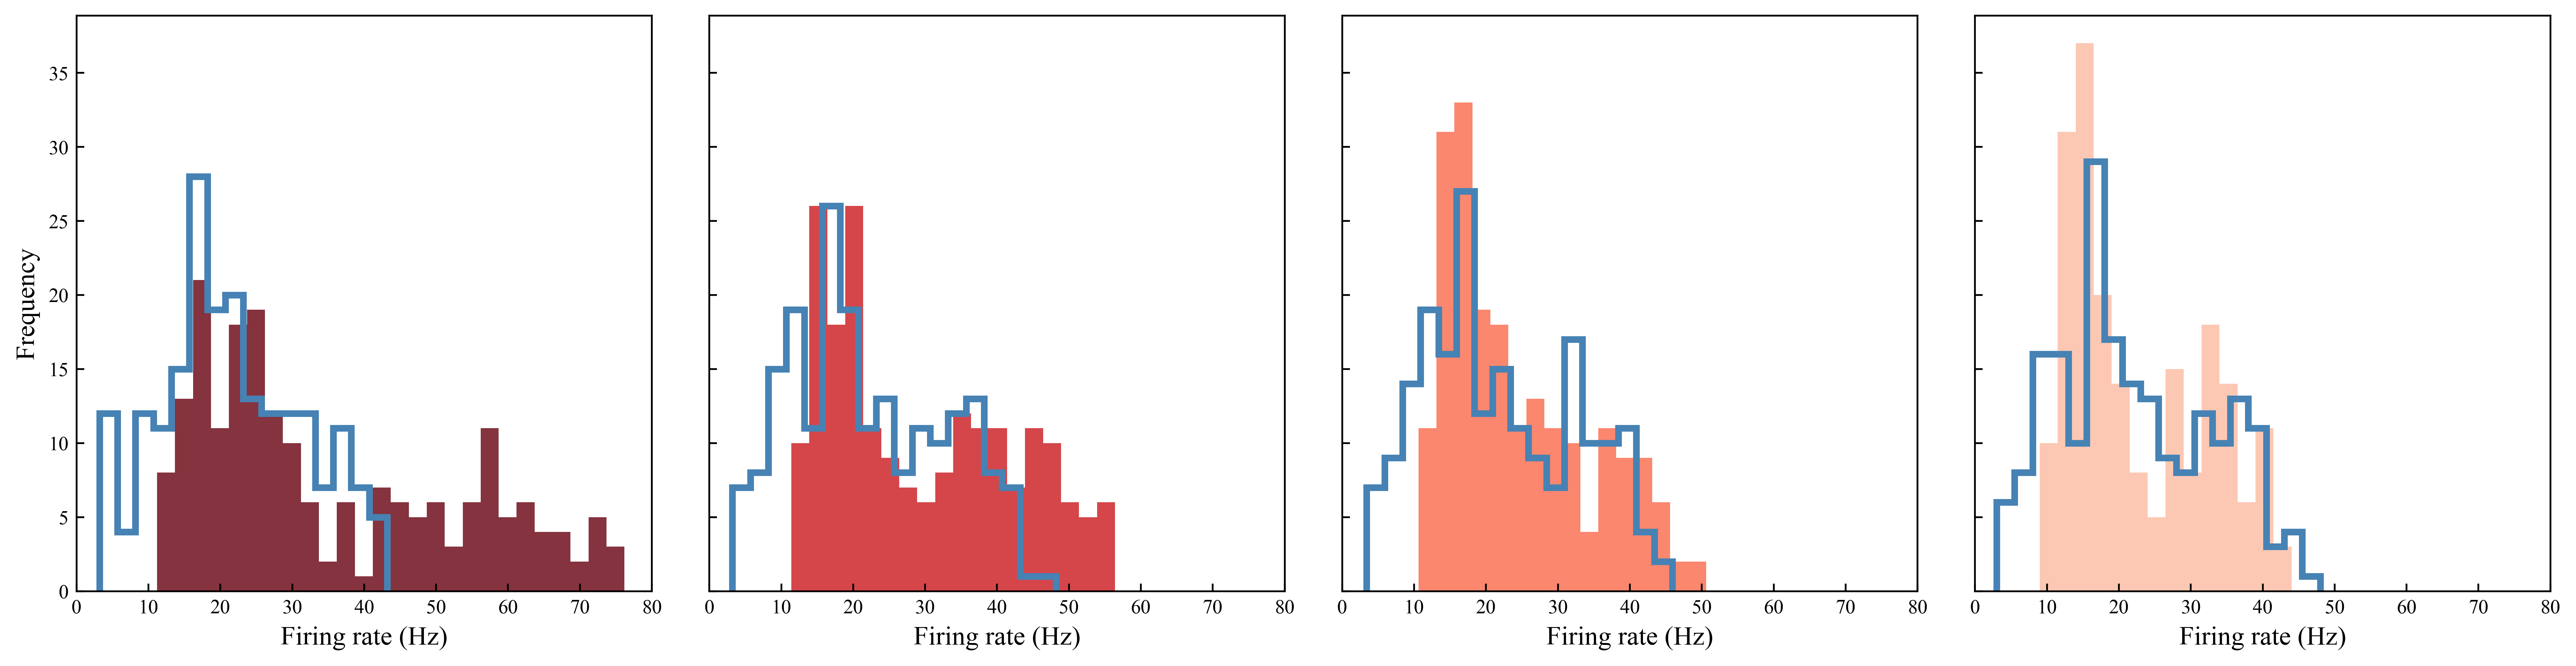

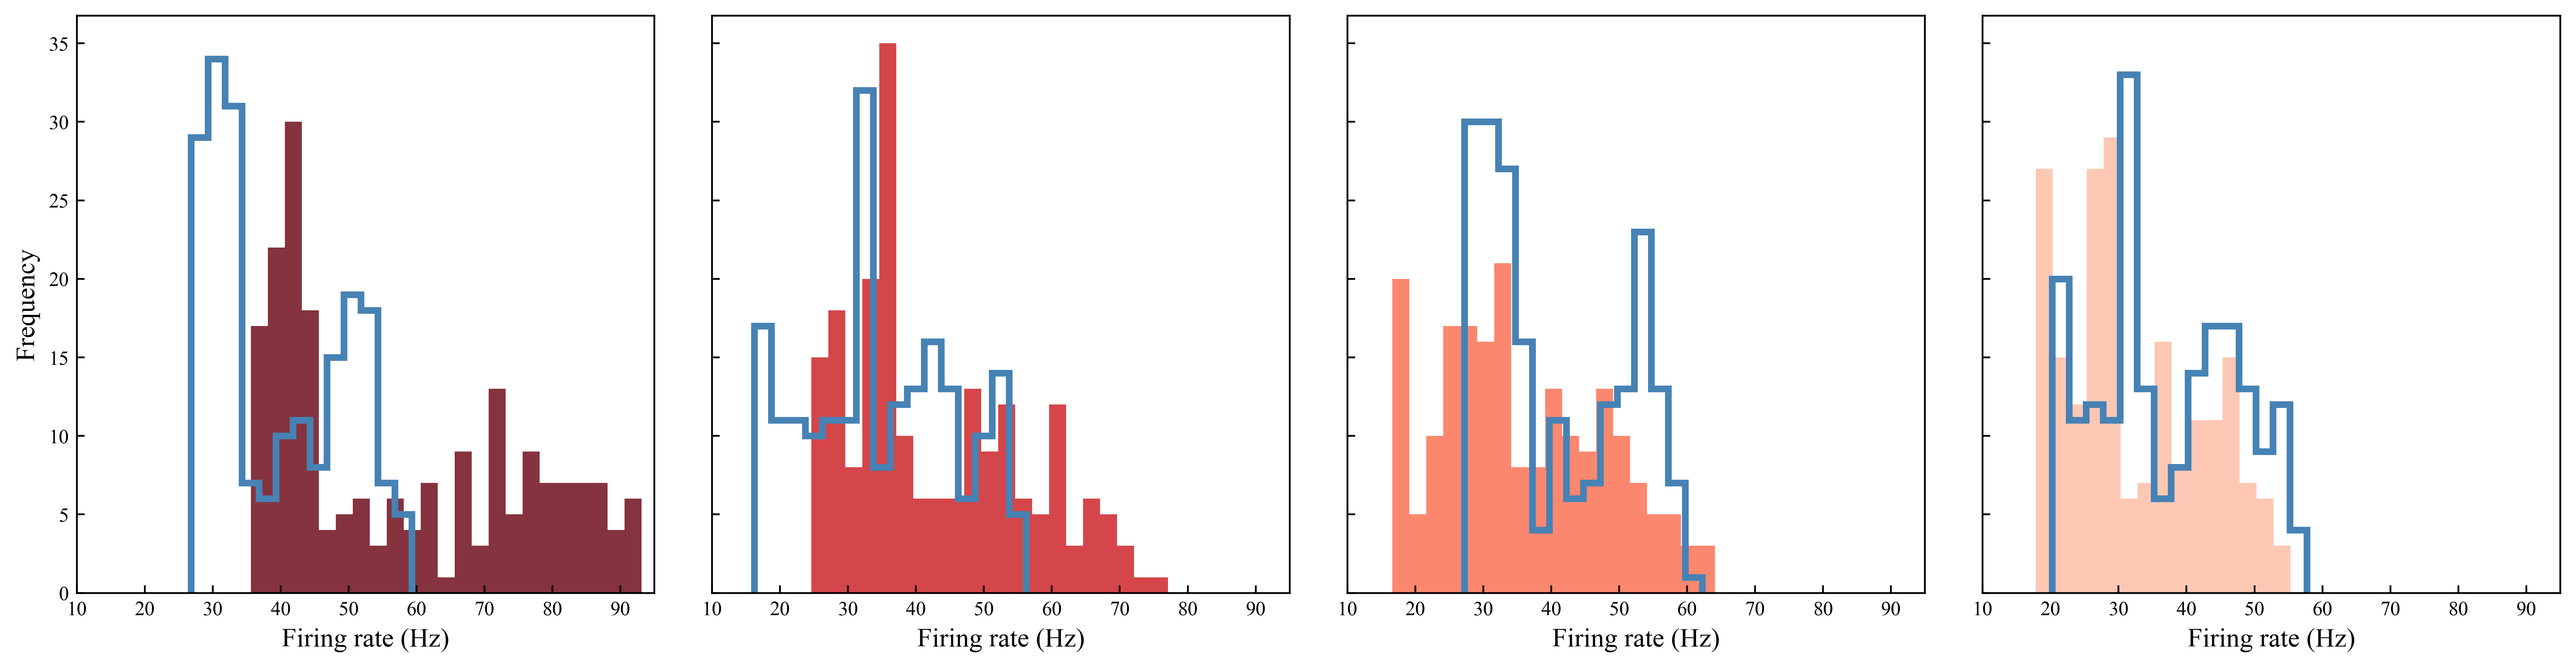

finished


In [27]:
# ========== Firing rate distributions ==========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
import random

from brokenaxes import brokenaxes
import sys

########## Initialization of lists of values needed ##########


# Simulation variables
simulation_number = [i for i in range(1, 5)]  # 1, 5 for osc;  9, 13 for seq
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
names_homogenous = ["LIF", "QIF"]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]

# seed_number = [i for i in range(0, 1)]  # If only one seed, set to (0, 1)
seed_number = [random.randint(1, 49)]
seed_number = [48]
print(f"Used seed {seed_number}")

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']


########## Time variables ##########
ms_per_file = 1000  # miliseconds
sec_after_learning = 5  # seconds after learning is from (inclusive) 11 to 16 (exclusive)
total_ms = ms_per_file * sec_after_learning  # 1000 * 5 = 5000 ms in total
T_seconds = total_ms / 1000  # To get in seconds so we get Hz


########## Make dataframe ##########

results = []  # Store all results
dicts = []  # store all dicts

rows = []


for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()


    for seed in seed_number:

        figname = f"{dyn}_homogenous_firing_rate.svg"
        fig, axs = plt.subplots(
            nrows=1,
            ncols=4,
            sharey=True,
            sharex=False,
            figsize=(20, 8)
        )

        fig.subplots_adjust(
            wspace=0.1,
        )

        for j, (sim, vr, f) in enumerate(zip(simulation_number, vr_number, slope)):
            ax = axs[j]

            corr_list = []  # See how LIF and QIF correlate in each simulation

            for pq, name in zip(pqif_homogenous, names_homogenous):


                ########## Formatting
                if pq == 0:
                    histtype='bar'
                    color = color_map_vrest[vr]
                    linestyle=''
                    linewidth=''
                    label = f"LIF, $F'$={f}"

                elif pq == 1:
                    #do something
                    histtype='step'
                    color='steelblue'
                    label = f"QIF"
                else:
                    print("Only use homogenous networks here")
                    sys.exit

                linestyle='-'
                linewidth=3

                kwargs = {
                    "histtype": histtype,
                    "color": color
                }

                if histtype == 'step':
                    kwargs["linestyle"] = linestyle
                    kwargs["linewidth"] = linewidth
                else:
                    kwargs["alpha"] = 0.8


                ########## Get values

                spikes_df = pd.read_csv(f'spikes_after_learning/{dyn}_sim_{sim}_pqif_{pq}.csv')
                spikes_copy = spikes_df.copy()  # Make copy

                ########## Firing rate for neuron i: Sum across column i (that neuron's spikes over 5 sec), divide by total time ##########

                spike_counts = spikes_copy.sum(axis=0)  # returns a Pandas series indexed by column number containing spike sum for neuron i
                spikes_per_neuron = spike_counts.values  # numpy array shape (neurons, )
                firing_rate_hz = spikes_per_neuron / T_seconds  # elementwise division, gives each neurons firing rate


                ########## Figure ##########
                bin_width = 2.5  # Hz
                bins = np.arange(firing_rate_hz.min(), firing_rate_hz.max() + bin_width, bin_width)


                ax.hist(firing_rate_hz, bins=bins, log=False, density=False, label=label, **kwargs)

                ax.set_xlabel("Firing rate (Hz)")
                ax.set_box_aspect(1)
                
            axs[0].set_ylabel("Frequency")

            # corr = np.corrcoef(x,y)[0, 1]
            # corr_rounded = np.round(corr, decimals=3)
            stats_firing_rate = [dyn, sim, vr, f, corr]
            rows.append(stats_firing_rate)
            if dyn == 'oscillations':
                ax.set_xlim(0, 80)
            elif dyn == 'sequences':
                ax.set_xlim(10, 95)
            plt.savefig(os.path.join(figure_folder, figname))
        
        plt.show()


# columns = ['dyn', 'sim', 'vr', 'f', 'correlation']
# stats = pd.DataFrame(rows, columns=columns)
# stats_copy = stats.copy()


print("finished")

In [10]:
# ========== Firing rate distributions ==========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
import random

from brokenaxes import brokenaxes
import sys

########## Initialization of lists of values needed ##########


# Simulation variables
simulation_number = [i for i in range(1, 5)]  # 1, 5 for osc;  9, 13 for seq
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
names_homogenous = ["LIF", "QIF"]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]

seed_number = [i for i in range(0, 5)]  # For now I only save 5 seeds due to storage, since we only use 1 seed in this one
# seed_number = [random.randint(1, 49)]
# print(f"Used seed {seed_number}")
# seed_number = 2

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']


########## Time variables ##########
ms_per_file = 1000  # miliseconds
sec_after_learning = 5  # seconds after learning is from (inclusive) 11 to 16 (exclusive)
total_ms = ms_per_file * sec_after_learning  # 1000 * 5 = 5000 ms in total
T_seconds = total_ms / 1000  # To get in seconds so we get Hz


########## Make dataframe ##########

results = []  # Store all results
dicts = []  # store all dicts

rows = []



for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)] # Correct simulaton numbers from dynamics

    for seed in seed_number:

        for j, (sim, vr, f) in enumerate(zip(simulation_number, vr_number, slope)):

            corr_list = []  # See how LIF and QIF correlate in each simulatio
            for pq, name in zip(pqif_homogenous, names_homogenous):

                ########## Get values
                
                try:
                    spike_blocks = [np.loadtxt(f'{dyn}\simulation_{sim}\simulation_{sim}_nspikes\simulation_{sim}_nspikes_pqif_{pq}_iloop_{i}_seed_{seed}.csv', delimiter=',') for i in range(11, 16)]  # load all nspikes files after learning, 11-16. Becomes nested list with
                    spikes_all = np.vstack(spike_blocks)  # Stack them: Gives shape (5000, 200) i.e. the full 5 seconds for all 200 neurons
                    # Not great solution to have this in the loop, so might change this later (for example to append directly to csv)

                except FileNotFoundError:  # In case there are missing files, let the program still plot for the rest, but notify
                    print(f"File not found: {sim}: {pq}, will be skipped.")
                    continue  # Go to next iteration


                # Convert the numpy array containing all spikes into a dataframe 

                spikes_df = pd.DataFrame(spikes_all)

                spikes_df.to_csv(f"firing_rate_files/{dyn}/sim_{sim}_pqif{pq}_seed_{seed}", index=False, header=False)
                print(f"Saved for {dyn}, sim = {sim}, pqif={pq}, seed={seed}")

Saved for oscillations, sim = 1, pqif=0, seed=0
Saved for oscillations, sim = 1, pqif=1, seed=0
Saved for oscillations, sim = 2, pqif=0, seed=0
Saved for oscillations, sim = 2, pqif=1, seed=0
Saved for oscillations, sim = 3, pqif=0, seed=0
Saved for oscillations, sim = 3, pqif=1, seed=0
Saved for oscillations, sim = 4, pqif=0, seed=0
Saved for oscillations, sim = 4, pqif=1, seed=0
Saved for oscillations, sim = 1, pqif=0, seed=1
Saved for oscillations, sim = 1, pqif=1, seed=1
Saved for oscillations, sim = 2, pqif=0, seed=1
Saved for oscillations, sim = 2, pqif=1, seed=1
Saved for oscillations, sim = 3, pqif=0, seed=1
Saved for oscillations, sim = 3, pqif=1, seed=1
Saved for oscillations, sim = 4, pqif=0, seed=1
Saved for oscillations, sim = 4, pqif=1, seed=1
Saved for oscillations, sim = 1, pqif=0, seed=2
Saved for oscillations, sim = 1, pqif=1, seed=2
Saved for oscillations, sim = 2, pqif=0, seed=2
Saved for oscillations, sim = 2, pqif=1, seed=2
Saved for oscillations, sim = 3, pqif=0,

Used seed [31]


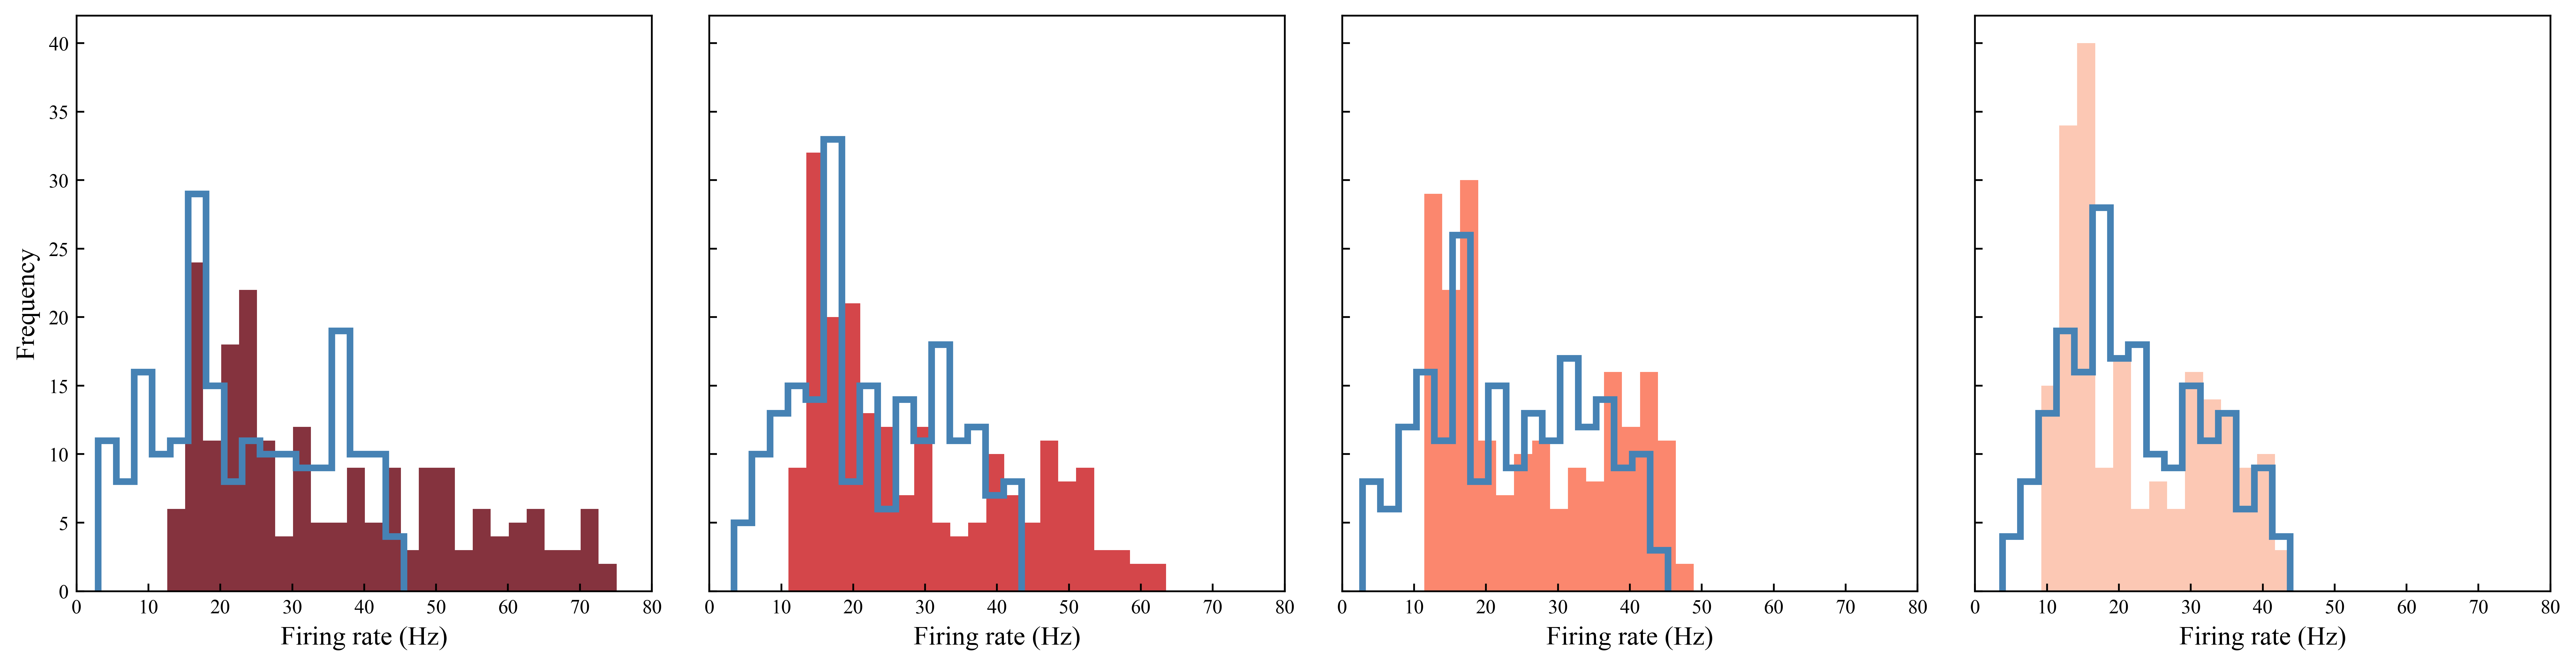

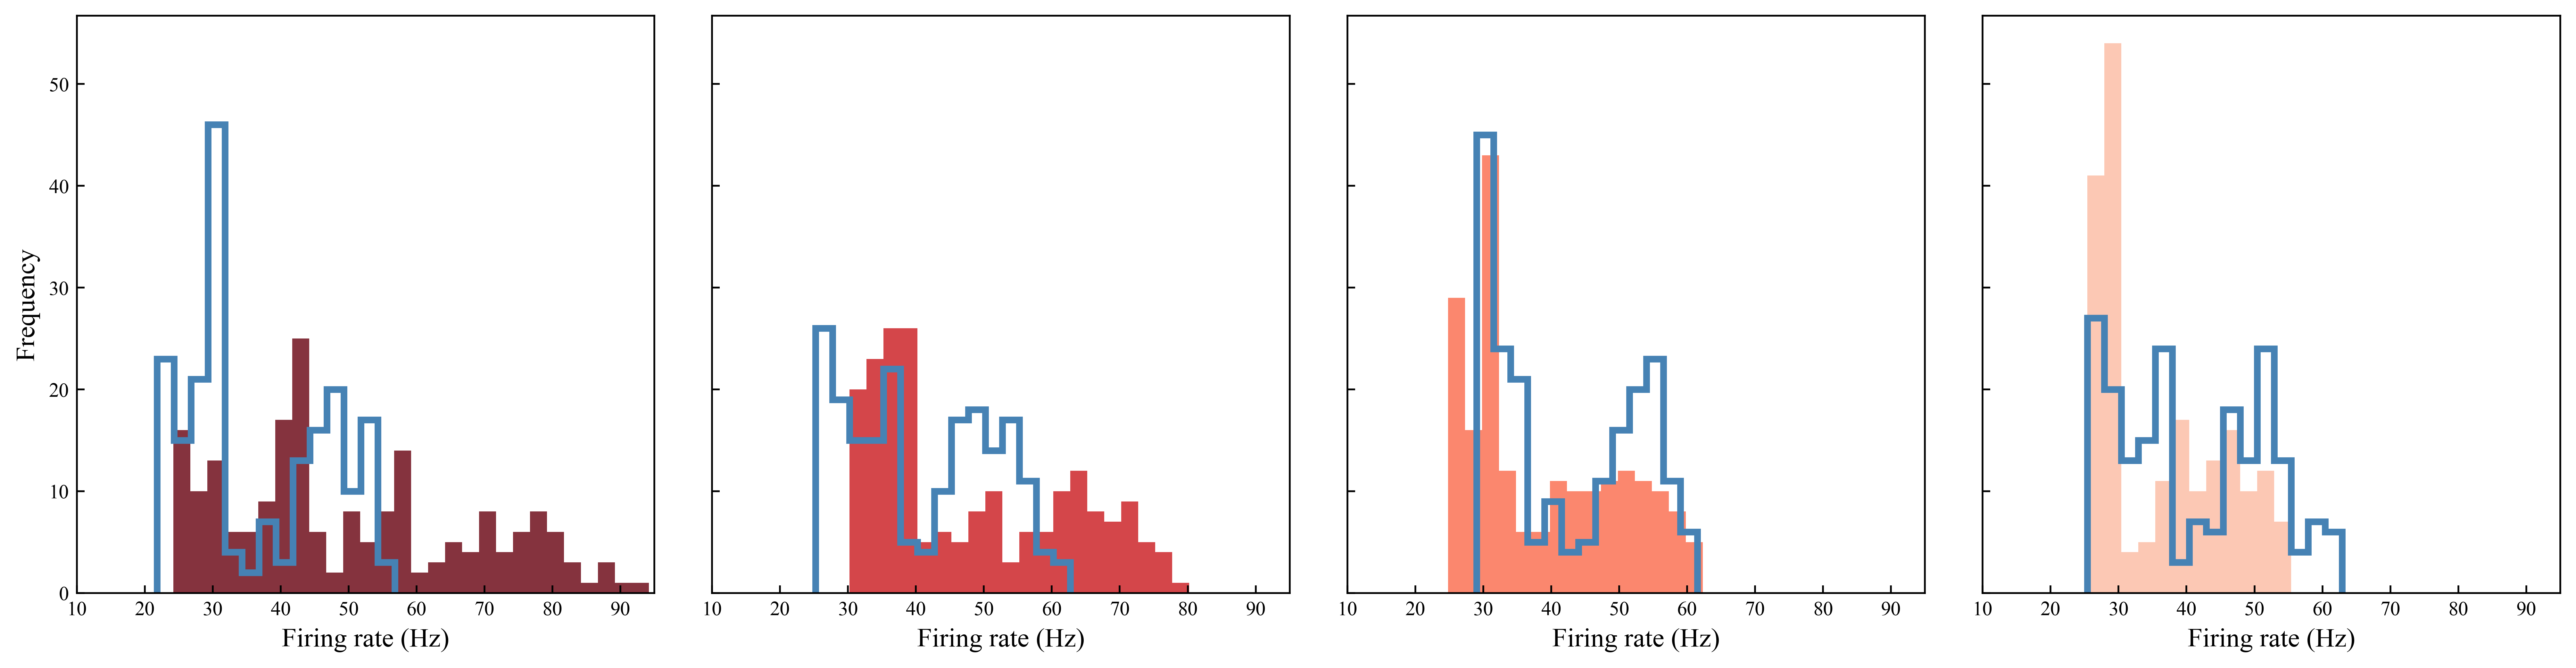

finished


In [ ]:
# ========== Firing rate distributions ==========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
import random

from brokenaxes import brokenaxes
import sys

########## Initialization of lists of values needed ##########


# Simulation variables
simulation_number = [i for i in range(1, 5)]  # 1, 5 for osc;  9, 13 for seq
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
names_homogenous = ["LIF", "QIF"]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]

# seed_number = [i for i in range(0, 1)]  # If only one seed, set to (0, 1)
seed_number = [random.randint(1, 49)]
print(f"Used seed {seed_number}")
seed_number = 2

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']


########## Time variables ##########
ms_per_file = 1000  # miliseconds
sec_after_learning = 5  # seconds after learning is from (inclusive) 11 to 16 (exclusive)
total_ms = ms_per_file * sec_after_learning  # 1000 * 5 = 5000 ms in total
T_seconds = total_ms / 1000  # To get in seconds so we get Hz


########## Make dataframe ##########

results = []  # Store all results
dicts = []  # store all dicts

rows = []


for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()


    for seed in seed_number:

        figname = f"{dyn}_homogenous_firing_rate.svg"
        fig, axs = plt.subplots(
            nrows=1,
            ncols=4,
            sharey=True,
            sharex=False,
            figsize=(20, 8)
        )

        fig.subplots_adjust(
            wspace=0.1,
        )

        for j, (sim, vr, f) in enumerate(zip(simulation_number, vr_number, slope)):
            ax = axs[j]

            corr_list = []  # See how LIF and QIF correlate in each simulation

            for pq, name in zip(pqif_homogenous, names_homogenous):


                ########## Formatting
                if pq == 0:
                    histtype='bar'
                    color = color_map_vrest[vr]
                    linestyle=''
                    linewidth=''
                    label = f"LIF, $F'$={f}"

                elif pq == 1:
                    #do something
                    histtype='step'
                    color='steelblue'
                    label = f"QIF"
                else:
                    print("Only use homogenous networks here")
                    sys.exit

                linestyle='-'
                linewidth=3

                kwargs = {
                    "histtype": histtype,
                    "color": color
                }

                if histtype == 'step':
                    kwargs["linestyle"] = linestyle
                    kwargs["linewidth"] = linewidth
                else:
                    kwargs["alpha"] = 0.8


                ########## Get values
                
                try:
                    spike_blocks = [np.loadtxt(f'{dyn}\simulation_{sim}\simulation_{sim}_nspikes\simulation_{sim}_nspikes_pqif_{pq}_iloop_{i}_seed_{seed}.csv', delimiter=',') for i in range(11, 16)]  # load all nspikes files after learning, 11-16. Becomes nested list with
                    spikes_all = np.vstack(spike_blocks)  # Stack them: Gives shape (5000, 200) i.e. the full 5 seconds for all 200 neurons

                except FileNotFoundError:  # In case there are missing files, let the program still plot for the rest, but notify
                    print(f"File not found: {sim}: {pq}, will be skipped.")
                    continue  # Go to next iteration


                # Convert the numpy array containing all spikes into a dataframe 

                spikes_df = pd.DataFrame(spikes_all)

                # Print and display just to confirm how it looks
                # print(f"Pqif {pq} vr: {vr}")
                # display(spikes_df)

                ########## Firing rate for neuron i: Sum across column i (that neuron's spikes over 5 sec), divide by total time ##########

                spike_counts = spikes_df.sum(axis=0)  # returns a Pandas series indexed by column number containing spike sum for neuron i

                spikes_per_neuron = spike_counts.values  # numpy array shape (neurons, )

                firing_rate_hz = spikes_per_neuron / T_seconds  # elementwise division, gives each neurons firing rate

                
                corr_list.append(firing_rate_hz)
            


                ########## Figure ##########
                bin_width = 2.5  # Hz
                bins = np.arange(firing_rate_hz.min(), firing_rate_hz.max() + bin_width, bin_width)

                ax.hist(firing_rate_hz, bins=bins, log=False, density=False, label=label, **kwargs)
                ax.set_xlabel("Firing rate (Hz)")
                ax.set_box_aspect(1)

                # print(f"{dyn.upper()}\nsim {sim}, pq {pq}\nMax firing rate: {firing_rate_hz.max()}\nMin firing rate: {firing_rate_hz.min()}\nMean firing rate: {firing_rate_hz.mean()}")
                
            axs[0].set_ylabel("Frequency")
            x, y = corr_list
            corr = np.corrcoef(x,y)[0, 1]
            corr_rounded = np.round(corr, decimals=3)
            stats_firing_rate = [dyn, sim, vr, f, corr]
            rows.append(stats_firing_rate)
            if dyn == 'oscillations':
                ax.set_xlim(0, 80)
            elif dyn == 'sequences':
                ax.set_xlim(10, 95)
            # ax.set_xlim(0, 70)
            # ax.text(50, 15, f"Correlation: {corr_rounded}")
            plt.savefig(os.path.join(figure_folder, figname))
        
        plt.show()


columns = ['dyn', 'sim', 'vr', 'f', 'correlation']
stats = pd.DataFrame(rows, columns=columns)
stats_copy = stats.copy()


print("finished")

Used seed [38]


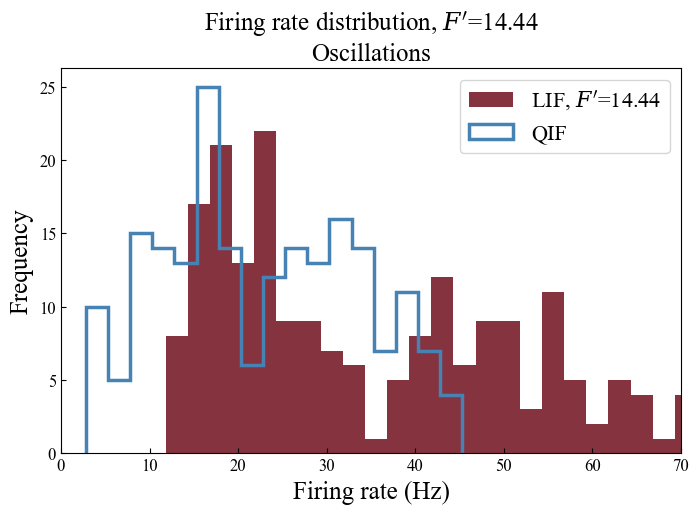

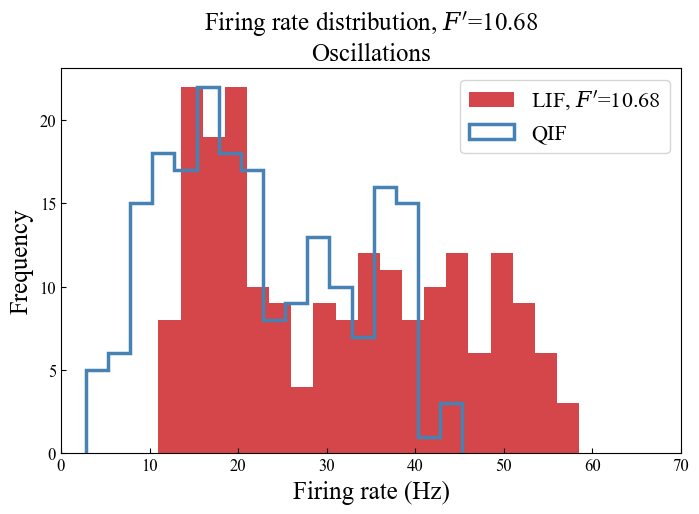

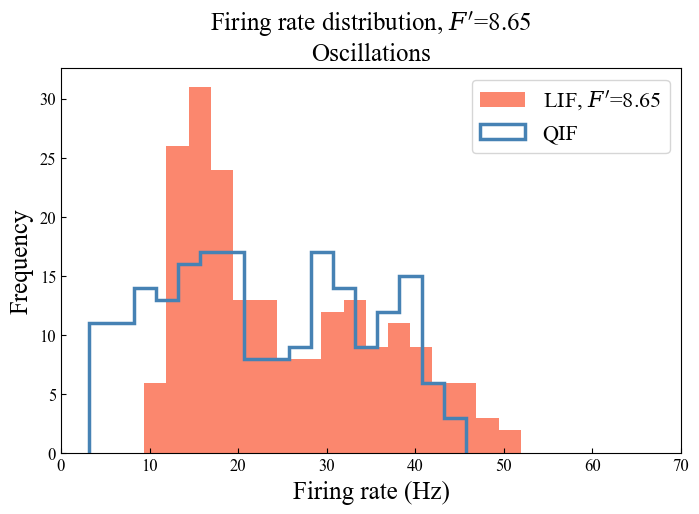

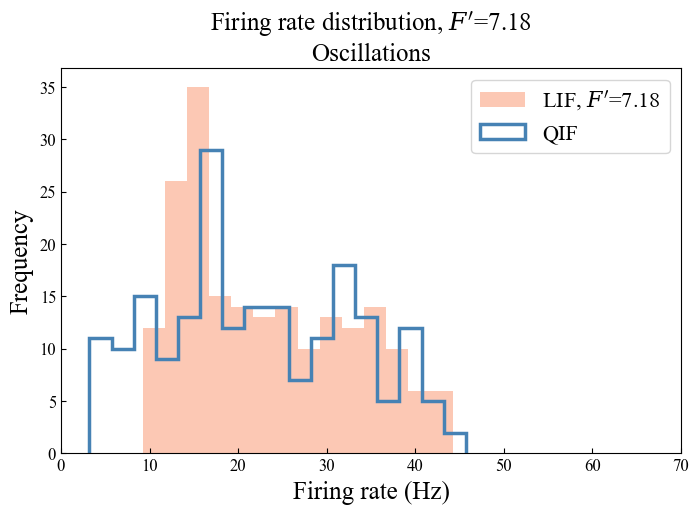

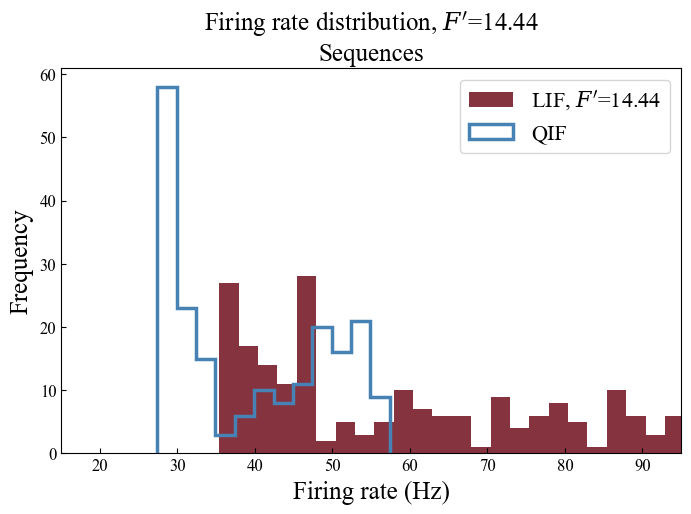

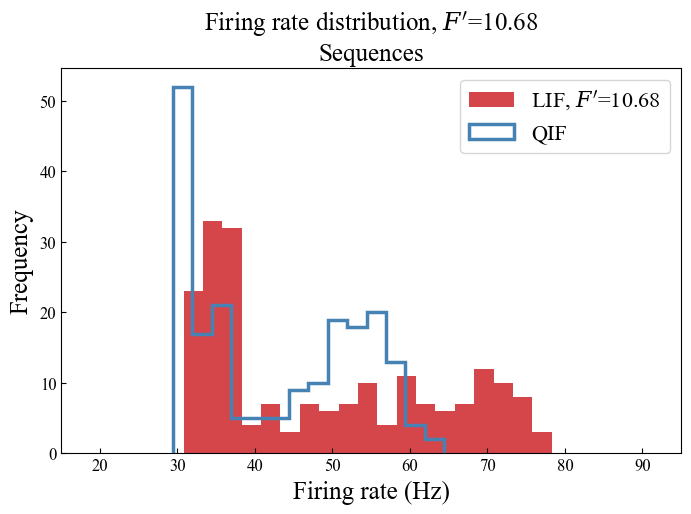

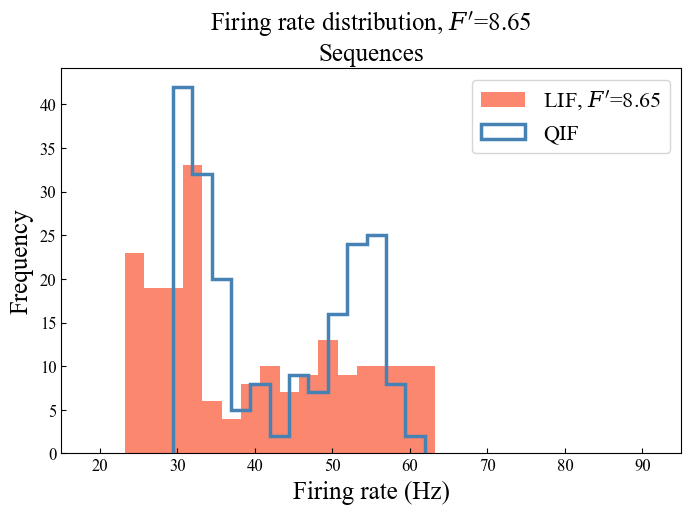

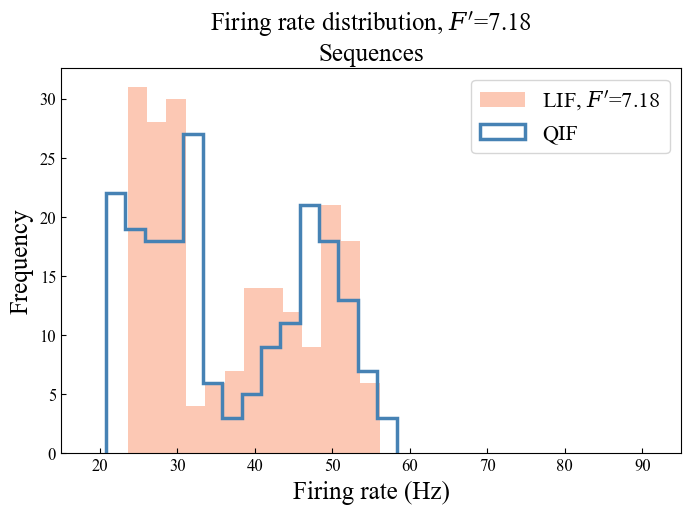

finished


In [18]:
# ========== Firing rate distributions ==========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
import random

from brokenaxes import brokenaxes
import sys

########## Initialization of lists of values needed ##########


# Simulation variables
simulation_number = [i for i in range(1, 5)]  # 1, 5 for osc;  9, 13 for seq
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
names_homogenous = ["LIF", "QIF"]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]

# seed_number = [i for i in range(0, 1)]  # If only one seed, set to (0, 1)
seed_number = [random.randint(1, 49)]
print(f"Used seed {seed_number}")

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']


########## Time variables ##########
ms_per_file = 1000  # miliseconds
sec_after_learning = 5  # seconds after learning is from (inclusive) 11 to 16 (exclusive)
total_ms = ms_per_file * sec_after_learning  # 1000 * 5 = 5000 ms in total
T_seconds = total_ms / 1000  # To get in seconds so we get Hz


########## Make dataframe ##########

results = []  # Store all results
dicts = []  # store all dicts

rows = []


for dyn in dynamics:

    #### Correct simulaton numbers from dynamics

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()


    for seed in seed_number:
        for sim, vr, f in zip(simulation_number, vr_number, slope):
            figname = f"{dyn}_firing_rate_homogenus_sim_{sim}.svg"
            fig, axs = plt.subplots(figsize=(8,5))
            ax = axs

            corr_list = []  # See how LIF and QIF correlate in each simulation

            for pq, name in zip(pqif_homogenous, names_homogenous):


                # Formatting
                if pq == 0:
                    histtype='bar'
                    color = color_map_vrest[vr]
                    linestyle=''
                    linewidth=''
                    label = f"LIF, $F'$={f}"

                elif pq == 1:
                    #do something
                    histtype='step'
                    color='steelblue'
                    label = f"QIF"
                else:
                    print("Only use homogenous networks here")
                    sys.exit

                linestyle='-'
                linewidth=2.5

                kwargs = {
                    "histtype": histtype,
                    "color": color
                }

                if histtype == 'step':
                    kwargs["linestyle"] = linestyle
                    kwargs["linewidth"] = linewidth
                else:
                    kwargs["alpha"] = 0.8

                try:

                    spike_blocks = [np.loadtxt(f'{dyn}\simulation_{sim}\simulation_{sim}_nspikes\simulation_{sim}_nspikes_pqif_{pq}_iloop_{i}_seed_{seed}.csv', delimiter=',') for i in range(11, 16)]  # load all nspikes files after learning, 11-16
                    spikes_all = np.vstack(spike_blocks)  # Stack them: Gives shape (5000, 200) i.e. the full 5 seconds for all 200 neurons

                except FileNotFoundError:  # In case there are missing files, let the program still plot for the rest, but notify
                    print(f"File not found: {sim}: {pq}, will be skipped.")
                    continue  # Go to next iteration


                # Convert the numpy array containing all spikes into a dataframe 

                spikes_df = pd.DataFrame(spikes_all)

                # Print and display just to confirm how it looks
                # print(f"Pqif {pq} vr: {vr}")
                # display(spikes_df)

                ########## Firing rate for neuron i: Sum across column i (that neuron's spikes over 5 sec), divide by total time ##########

                spike_counts = spikes_df.sum(axis=0)  # returns a Pandas series indexed by column number containing spike sum for neuron i

                spikes_per_neuron = spike_counts.values  # numpy array shape (neurons, )

                firing_rate_hz = spikes_per_neuron / T_seconds  # elementwise division, gives each neurons firing rate

                
                corr_list.append(firing_rate_hz)
            


                ########## Figure ##########
                bin_width = 2.5  # Hz
                # bin_width = 3
                # bin_width = 1.2
                # bins = np.arange(0.2, firing_rate_hz.max() + bin_width, bin_width)
                bins = np.arange(firing_rate_hz.min(), firing_rate_hz.max() + bin_width, bin_width)
                # bins = np.arange(firing_rate_hz.min(), 50, bin_width)
                # bins = [0, 15, 15, 20, 20, 25, 25, 35, 35, 60]


                ax.hist(firing_rate_hz, bins=bins, log=False, density=False, label=label, **kwargs)
                # ax.hist(firing_rate_hz, bins='auto', log=False, density=False, label=name, **kwargs)
                ax.set_title(f"Firing rate distribution, $F'$={f}\n{dyn.capitalize()}")
                ax.set_xlabel("Firing rate (Hz)")
                # ax.set_xlim(-6, 6)
                # ax.set_xticks(xticks)
                # ax.axvline(0, color='black', linestyle='--', linewidth=1)
                ax.set_ylabel("Frequency")
                ax.legend()

                # print(f"{dyn.upper()}\nsim {sim}, pq {pq}\nMax firing rate: {firing_rate_hz.max()}\nMin firing rate: {firing_rate_hz.min()}\nMean firing rate: {firing_rate_hz.mean()}")
                
            x, y = corr_list
            corr = np.corrcoef(x,y)[0, 1]
            corr_rounded = np.round(corr, decimals=3)
            stats_firing_rate = [dyn, sim, vr, f, corr]
            rows.append(stats_firing_rate)
            if dyn == 'oscillations':
                ax.set_xlim(0, 70)
            elif dyn == 'sequences':
                ax.set_xlim(15, 95)
            # ax.set_xlim(0, 70)
            # ax.text(50, 15, f"Correlation: {corr_rounded}")
            # plt.savefig(os.path.join(figure_folder, figname))
            plt.show()


columns = ['dyn', 'sim', 'vr', 'f', 'correlation']
stats = pd.DataFrame(rows, columns=columns)
stats_copy = stats.copy()


print("finished")

# New version

Uses stored files

Used seed 2


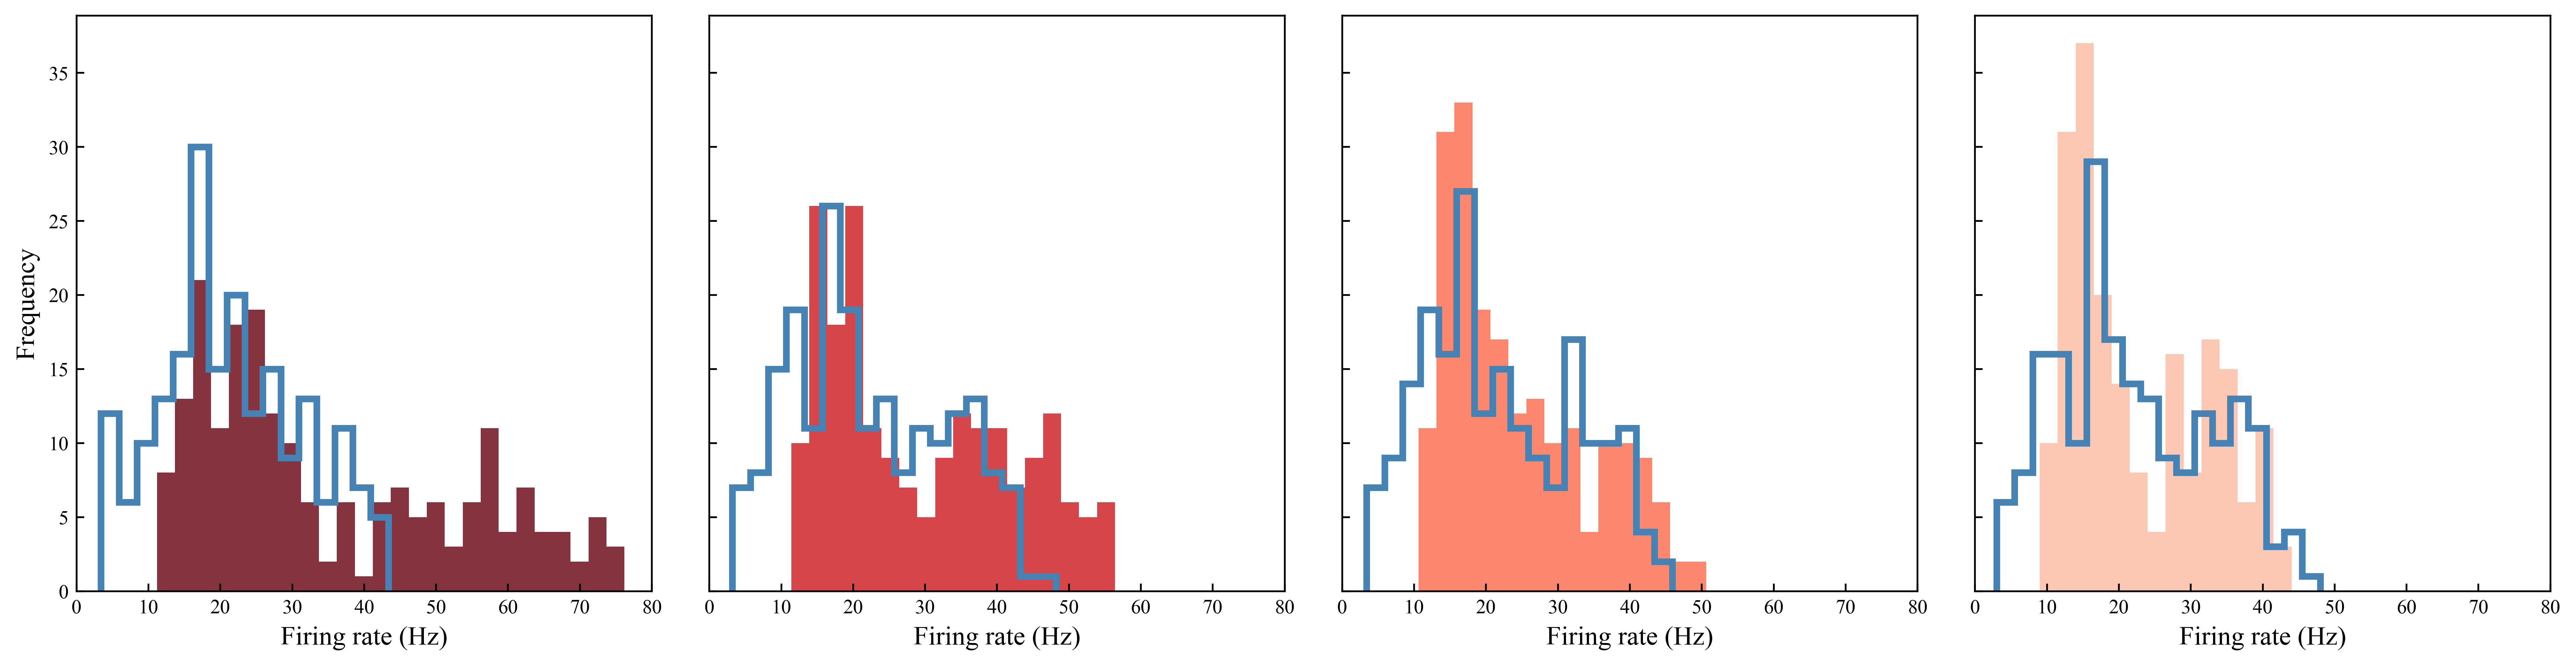

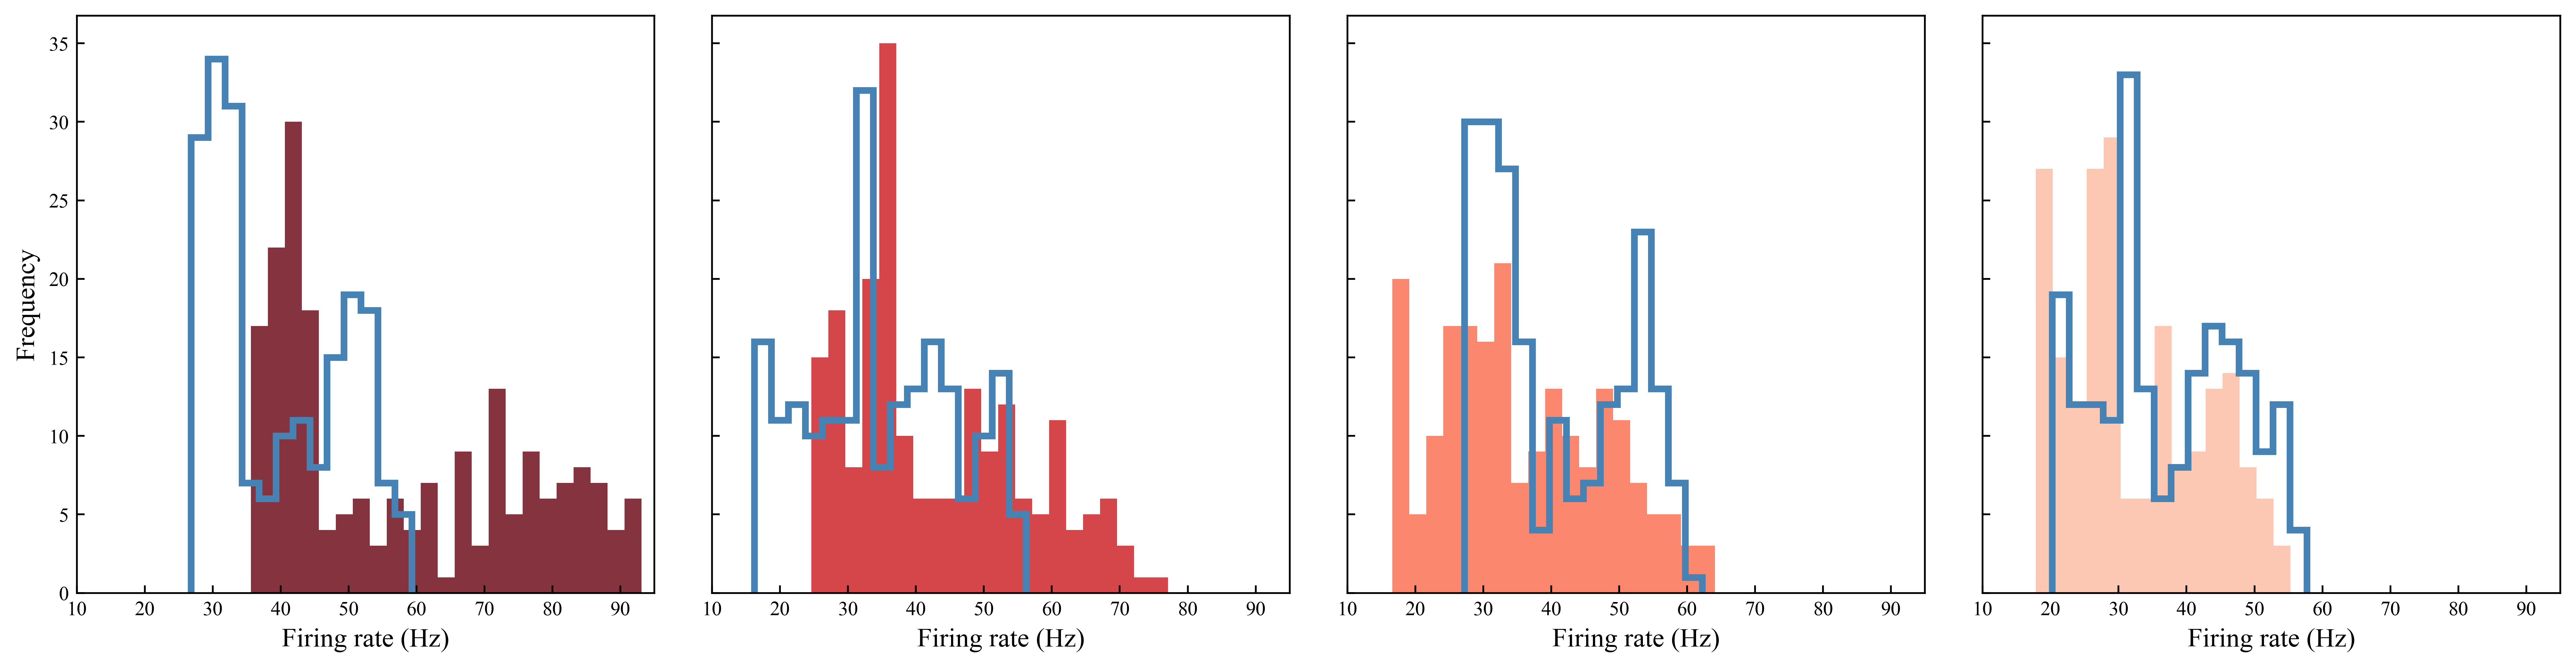

finished


In [11]:
# ========== Firing rate distributions ==========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
import random

from brokenaxes import brokenaxes
import sys

########## Initialization of lists of values needed ##########


# Simulation variables
simulation_number = [i for i in range(1, 5)]  # 1, 5 for osc;  9, 13 for seq
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
names_homogenous = ["LIF", "QIF"]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]

# seed_number = [i for i in range(0, 1)]  # If only one seed, set to (0, 1)
# seed_number = [random.randint(1, 49)]
seed_number = 2
print(f"Used seed {seed_number}")

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']


########## Time variables ##########
ms_per_file = 1000  # miliseconds
sec_after_learning = 5  # seconds after learning is from (inclusive) 11 to 16 (exclusive)
total_ms = ms_per_file * sec_after_learning  # 1000 * 5 = 5000 ms in total
T_seconds = total_ms / 1000  # To get in seconds so we get Hz


########## Make dataframe ##########

results = []  # Store all results
dicts = []  # store all dicts

rows = []


for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)] # Correct simulaton numbers from dynamics

    figname = f"{dyn}_homogenous_firing_rate.svg"
    fig, axs = plt.subplots(
        nrows=1,
        ncols=4,
        sharey=True,
        sharex=False,
        figsize=(20, 8)
    )

    fig.subplots_adjust(
        wspace=0.1,
    )

    for j, (sim, vr, f) in enumerate(zip(simulation_number, vr_number, slope)):
        ax = axs[j]

        for pq, name in zip(pqif_homogenous, names_homogenous):


            ########## Formatting
            if pq == 0:
                histtype='bar'
                color = color_map_vrest[vr]
                linestyle=''
                linewidth=''
                label = f"LIF, $F'$={f}"

            elif pq == 1:
                #do something
                histtype='step'
                color='steelblue'
                label = f"QIF"
            else:
                print("Only use homogenous networks here")
                sys.exit

            linestyle='-'
            linewidth=3

            kwargs = {
                "histtype": histtype,
                "color": color
            }

            if histtype == 'step':
                kwargs["linestyle"] = linestyle
                kwargs["linewidth"] = linewidth
            else:
                kwargs["alpha"] = 0.8


            ########## Get values
            

            spikes_df = pd.read_csv(f"firing_rate_files/{dyn}/sim_{sim}_pqif{pq}_seed_{seed_number}", header=None)


            ########## Firing rate for neuron i: Sum across column i (that neuron's spikes over 5 sec), divide by total time ##########

            spike_counts = spikes_df.sum(axis=0)  # returns a Pandas series indexed by column number containing spike sum for neuron i

            spikes_per_neuron = spike_counts.values  # numpy array shape (neurons, )

            firing_rate_hz = spikes_per_neuron / T_seconds  # elementwise division, gives each neurons firing rate

            
            # corr_list.append(firing_rate_hz)
        


            ########## Figure ##########
            bin_width = 2.5  # Hz
            bins = np.arange(firing_rate_hz.min(), firing_rate_hz.max() + bin_width, bin_width)

            ax.hist(firing_rate_hz, bins=bins, log=False, density=False, label=label, **kwargs)
            ax.set_xlabel("Firing rate (Hz)")
            ax.set_box_aspect(1)
            
        axs[0].set_ylabel("Frequency")
        if dyn == 'oscillations':
            ax.set_xlim(0, 80)
        elif dyn == 'sequences':
            ax.set_xlim(10, 95)

        plt.savefig(os.path.join(figure_folder, figname))
    
    plt.show()


# columns = ['dyn', 'sim', 'vr', 'f', 'correlation']
# stats = pd.DataFrame(rows, columns=columns)
# stats_copy = stats.copy()


print("finished")

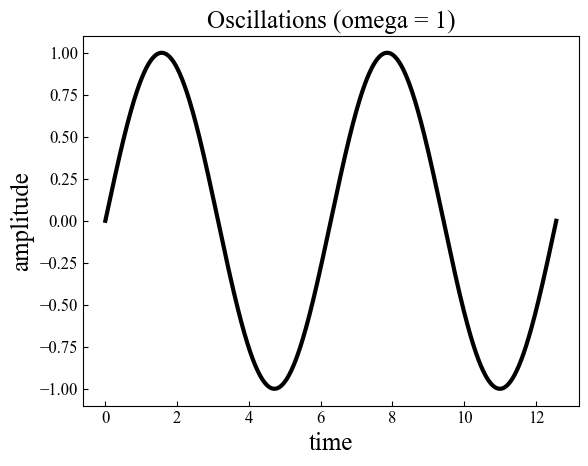

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# choose frequency multiplier
omega = 1   # try 1 (slow) or 5 (fast)

# time axis
T = 20
points = 5000

t = np.linspace(0, 4*np.pi, 1000)
# t = np.linspace(0, 10, 1)
# t = np.linspace(0, T, points)

# waves
theta = np.sin(omega * t)
gamma = np.sin(5 * omega * t)  # faster oscillation relative to theta

# plot
plt.figure()
plt.plot(t, theta, label="theta", linewidth=3, color='black')
# plt.plot(t, gamma, linewidth=3, label="gamma", color='black')

plt.xlabel("time")
plt.ylabel("amplitude")
# plt.legend()
plt.title(f"Oscillations (omega = {omega})")
plt.show()


# Correlation

## Not broken axis

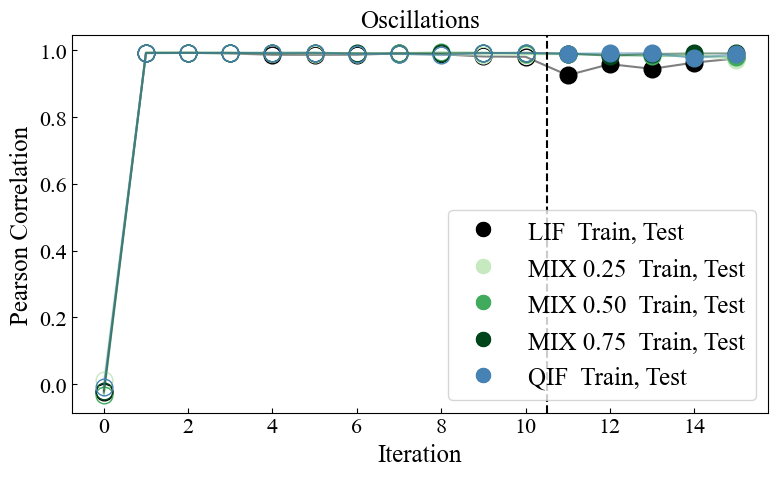

In [9]:
# ========== Correlation, Oscillations (NOT BROKEN AXIS) ==========

# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(1,5)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 1
itmax = 1000
itstim = 200 
nloop = 16



# Create figure
fig, ax = plt.subplots(figsize=(8,5))

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(f'oscillations/simulation_{idx}/simulation_{idx}_targets_{pq}.csv')
        targets = target_csv.values

        file = f'oscillations/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers
    ax.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

# Labels and scales
ax.set_title('Oscillations')
ax.axvline(10.5, color='black', linestyle="--")
ax.set_xlabel('Iteration')
ax.set_ylabel('Pearson Correlation')

# Optional: custom legend
legend_elements = []
labels = []
for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}  Train, Test")

ax.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')

plt.tight_layout()

plt.show()

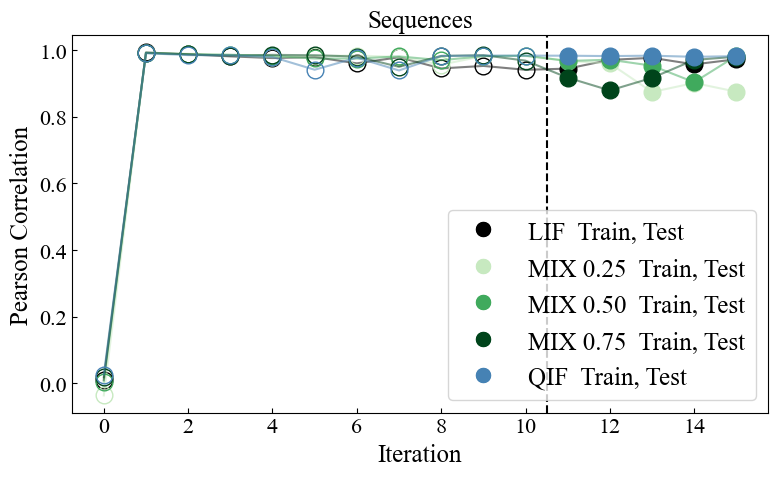

In [12]:
# ========== Correlation, Sequences (NOT BROKEN AXIS) ==========

# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(9,13)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", "MIX 0.25", "MIX 0.50", "MIX 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 9
itmax = 1000
itstim = 200 
nloop = 16



# Create figure
fig, ax = plt.subplots(figsize=(8,5))

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(f'sequences/simulation_{idx}/simulation_{idx}_targets_{pq}.csv')
        # target_csv = pd.read_csv(ONEDRIVE_BASE / f'simulation_{idx}/simulacion_{idx}_targets_{pq}.csv')
        targets = target_csv.values

        file = f'sequences/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        # file = ONEDRIVE_BASE / f'sequences/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers
    ax.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

# Labels and scales
ax.set_title('Sequences')
ax.axvline(10.5, color='black', linestyle="--")
ax.set_xlabel('Iteration')
ax.set_ylabel('Pearson Correlation')

# Optional: custom legend
legend_elements = []
labels = []
for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}  Train, Test")

ax.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')

plt.tight_layout()

plt.show()

## Broken axis

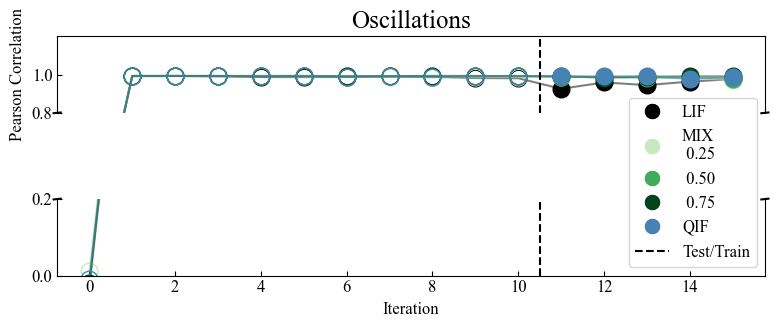

In [16]:
# ========== Correlation WITH BROKEN AXIS ==========

# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(9,13)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", f"MIX\n 0.25", " 0.50", " 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 1
itmax = 1000
itstim = 200 
nloop = 16

yticks_top = [0.80, 1]
yticks_bottom = [0, 0.2]


# Create figure
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(8,3.5)
    )

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(f'oscillations/simulation_{idx}/simulation_{idx}_targets_{pq}.csv')
        targets = target_csv.values

        file = f'oscillations/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers ON BOTH AXES
    ax_top.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_top.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_top.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_top.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

    ax_bottom.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_bottom.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_bottom.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_bottom.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

# Break y axis
ax_top.set_ylim(0.80, 1.2)  # Upper range
ax_bottom.set_ylim(0, 0.2)  # Lower range

ax_top.set_yticks(yticks_top)
ax_bottom.set_yticks(yticks_bottom)

# Hide spines between axes

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

# Disable ticks where break is
ax_top.tick_params(labeltop=False, bottom=False),
ax_bottom.tick_params(top=False)

# Diagonal break marks
d = 0.005 # size of diagonal lines in axes coordinate
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels and scales
ax_top.set_title('Oscillations')
ax_top.axvline(10.5, color='black', linestyle="--")
ax_bottom.axvline(10.5, color='black', linestyle="--")
ax_bottom.set_xlabel('Iteration')
ax_top.set_ylabel('Pearson Correlation')

# Optional: custom legend
legend_elements = []
labels = []
for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}")

vertical_line = Line2D([0], [0], color='black', linestyle='--')
legend_elements.append(vertical_line)
labels.append(f"Test/Train")

ax_bottom.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')

plt.tight_layout()

plt.show()

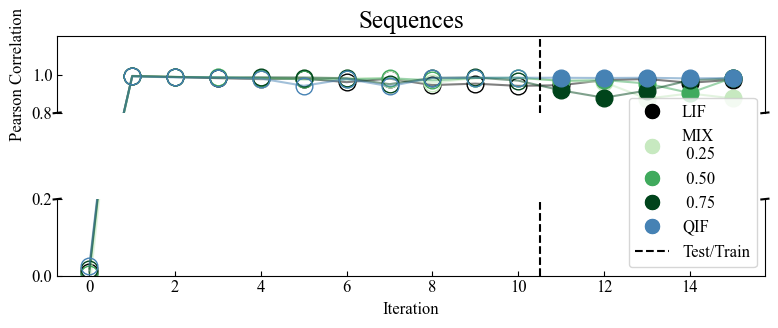

In [17]:
# ========== Correlation WITH BROKEN AXIS ==========

# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(9,13)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", f"MIX\n 0.25", " 0.50", " 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 9
itmax = 1000
itstim = 200 
nloop = 16

yticks_top = [0.80, 1]
yticks_bottom = [0, 0.2]


# Create figure
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(8,3.5)
    )

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(f'sequences/simulation_{idx}/simulation_{idx}_targets_{pq}.csv')
        targets = target_csv.values

        file = f'sequences/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers ON BOTH AXES
    ax_top.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_top.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_top.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_top.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

    ax_bottom.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_bottom.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_bottom.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_bottom.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

# Break y axis
ax_top.set_ylim(0.80, 1.2)  # Upper range
ax_bottom.set_ylim(0, 0.2)  # Lower range

ax_top.set_yticks(yticks_top)
ax_bottom.set_yticks(yticks_bottom)

# Hide spines between axes

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

# Disable ticks where break is
ax_top.tick_params(labeltop=False, bottom=False),
ax_bottom.tick_params(top=False)

# Diagonal break marks
d = 0.005 # size of diagonal lines in axes coordinate
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels and scales
ax_top.set_title('Sequences')
ax_top.axvline(10.5, color='black', linestyle="--")
ax_bottom.axvline(10.5, color='black', linestyle="--")
ax_bottom.set_xlabel('Iteration')
ax_top.set_ylabel('Pearson Correlation')

# Optional: custom legend
legend_elements = []
labels = []
for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}")

vertical_line = Line2D([0], [0], color='black', linestyle='--')
legend_elements.append(vertical_line)
labels.append(f"Test/Train")

ax_bottom.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')

plt.tight_layout()

plt.show()

### Broken axis, different legend and ylabel

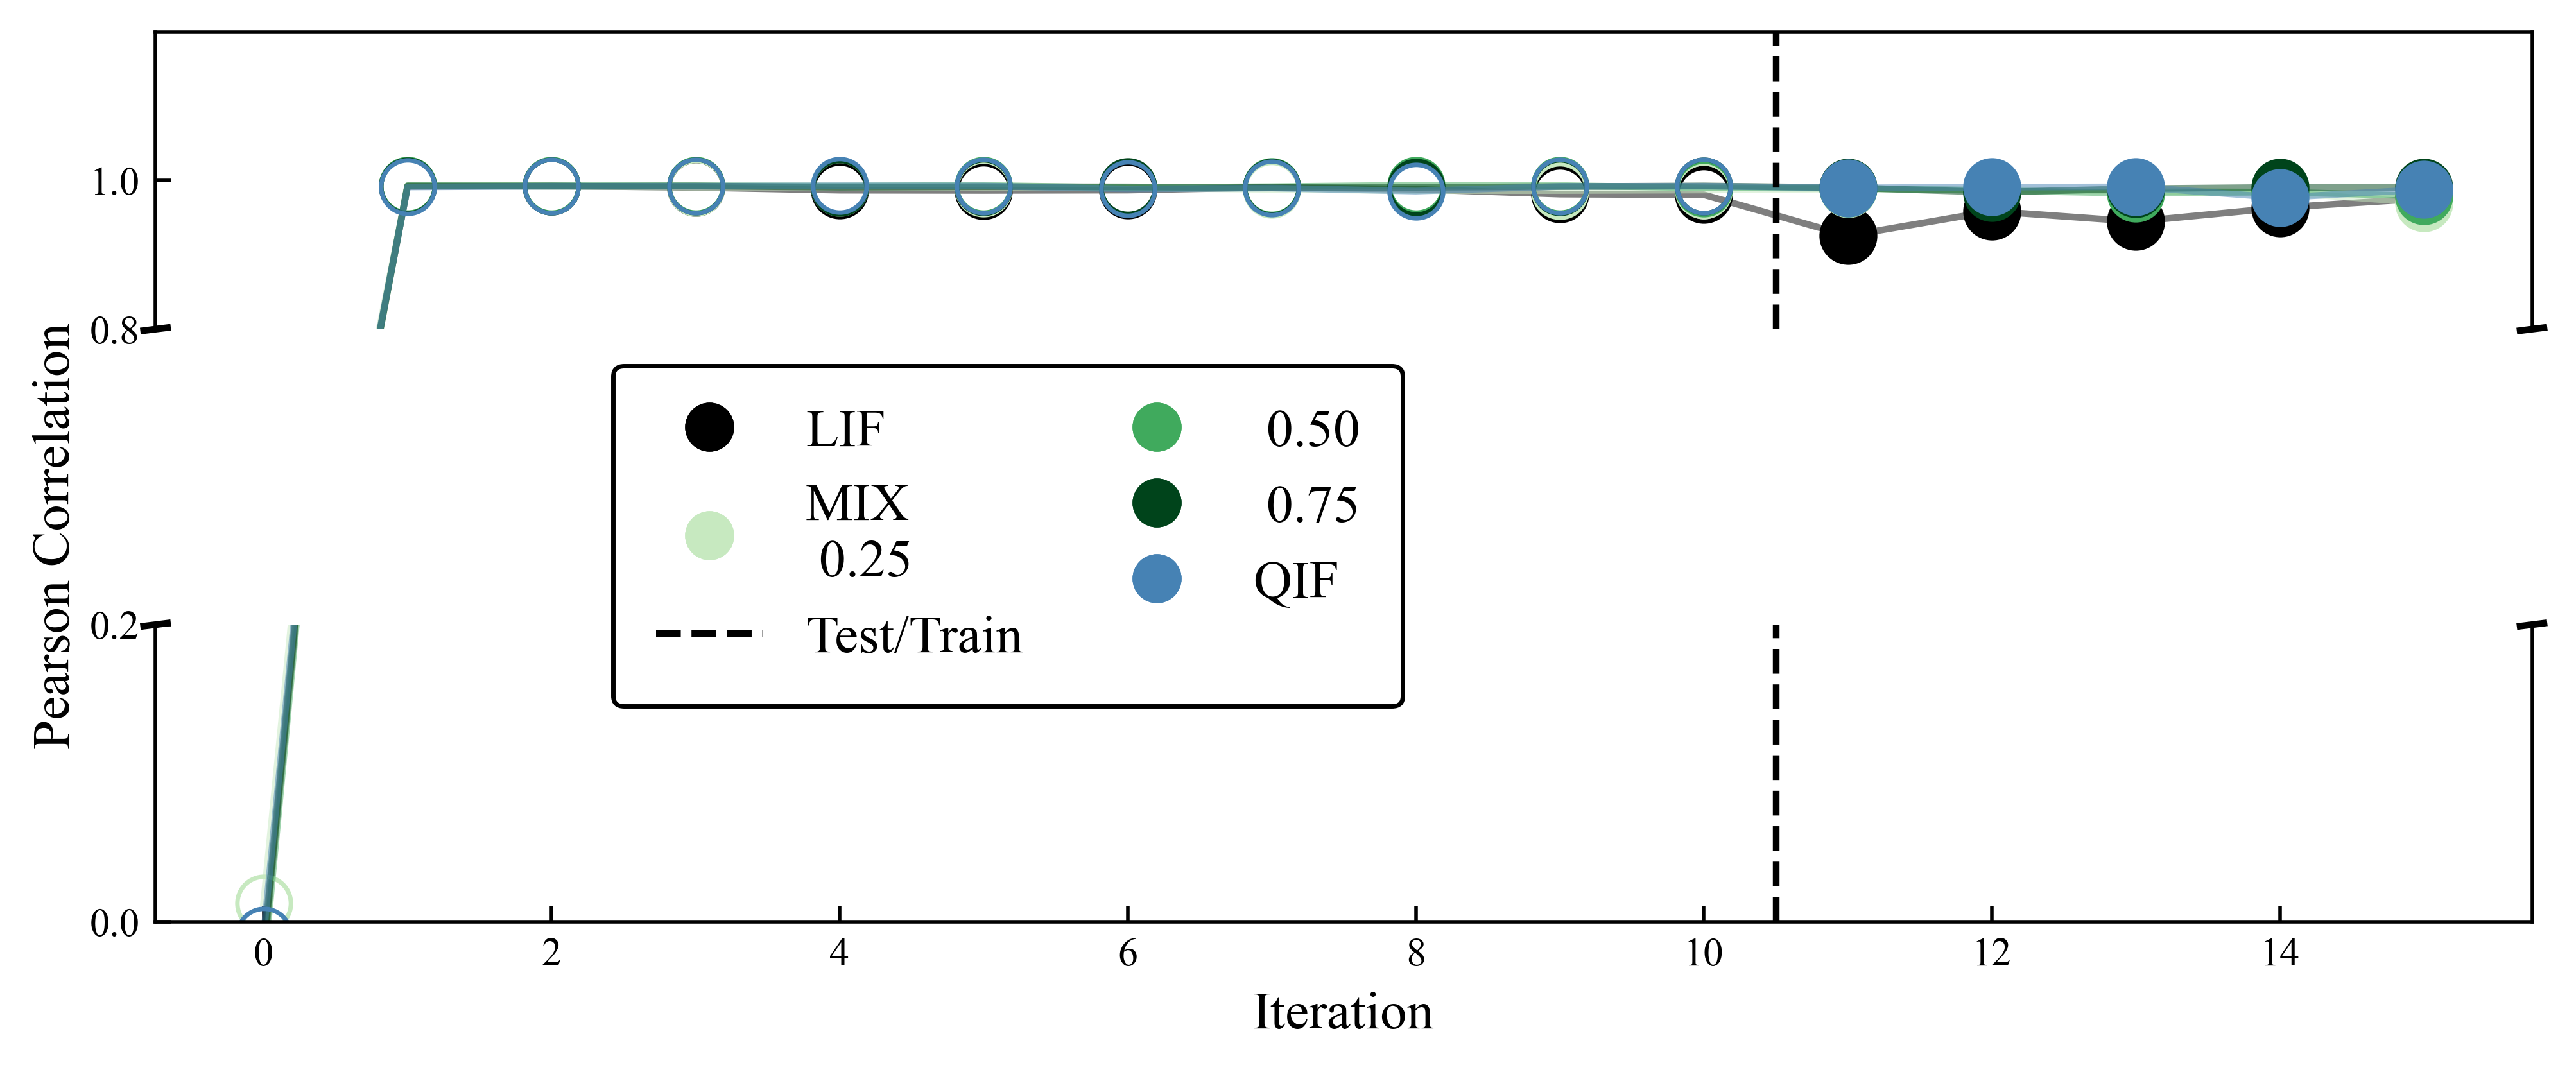

In [13]:
# ========== Correlation WITH BROKEN AXIS ==========

# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(9,13)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", f"MIX\n 0.25", " 0.50", " 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 1
itmax = 1000
itstim = 200 
nloop = 16

yticks_top = [0.80, 1]
yticks_bottom = [0, 0.2]


# Create figure
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(8,3.5)
    )

figname = f"oscillations_correlation"

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(f'oscillations/simulation_{idx}/simulation_{idx}_targets_{pq}.csv')
        targets = target_csv.values

        file = f'oscillations/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers ON BOTH AXES
    ax_top.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_top.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_top.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_top.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

    ax_bottom.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_bottom.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_bottom.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_bottom.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

# Break y axis
ax_top.set_ylim(0.80, 1.2)  # Upper range
ax_bottom.set_ylim(0, 0.2)  # Lower range

ax_top.set_yticks(yticks_top)
ax_bottom.set_yticks(yticks_bottom)

# Hide spines between axes

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

# Disable ticks where break is
ax_top.tick_params(labeltop=False, bottom=False),
ax_bottom.tick_params(top=False)

# Diagonal break marks
d = 0.005 # size of diagonal lines in axes coordinate
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels and scales
# ax_top.set_title('Oscillations')
ax_top.axvline(10.5, color='black', linestyle="--")
ax_bottom.axvline(10.5, color='black', linestyle="--")
ax_bottom.set_xlabel('Iteration')
# ax_top.set_ylabel('Pearson Correlation')
fig.text(
    0, 
    0.5, 
    "Pearson Correlation", 
    va='center', 
    rotation='vertical',
    fontsize=plt.rcParams['axes.labelsize']
    )

# Optional: custom legend
legend_elements = []
labels = []
for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}")

vertical_line = Line2D([0], [0], color='black', linestyle='--')
# legend_elements.append(vertical_line)
# labels.append(f"Test/Train")
legend_elements.insert(2, vertical_line)
labels.insert(2, f"Test/Train")

# ax_bottom.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')
ax_bottom.legend(
    legend_elements,
    labels,
    handler_map={tuple: HandlerTuple()},
    ncol=2,                             # number of columns
    loc='center',                       # anchor point
    bbox_to_anchor=(0.38, 0.5),          # center of axes or figure depending on next line
    bbox_transform=fig.transFigure,     # figure coordinates
    frameon=True,                       # rectangular legend box
    edgecolor='black',
    framealpha=1.0,
    # borderpad=1.2,
    borderpad=0.8,
    columnspacing=1.5,
    handletextpad=0.8
)

plt.tight_layout()
full_path = os.path.join(figure_folder, figname)
plt.savefig(full_path, format="svg")
# plt.savefig(os.path.join(figure_folder, figname))
plt.show()

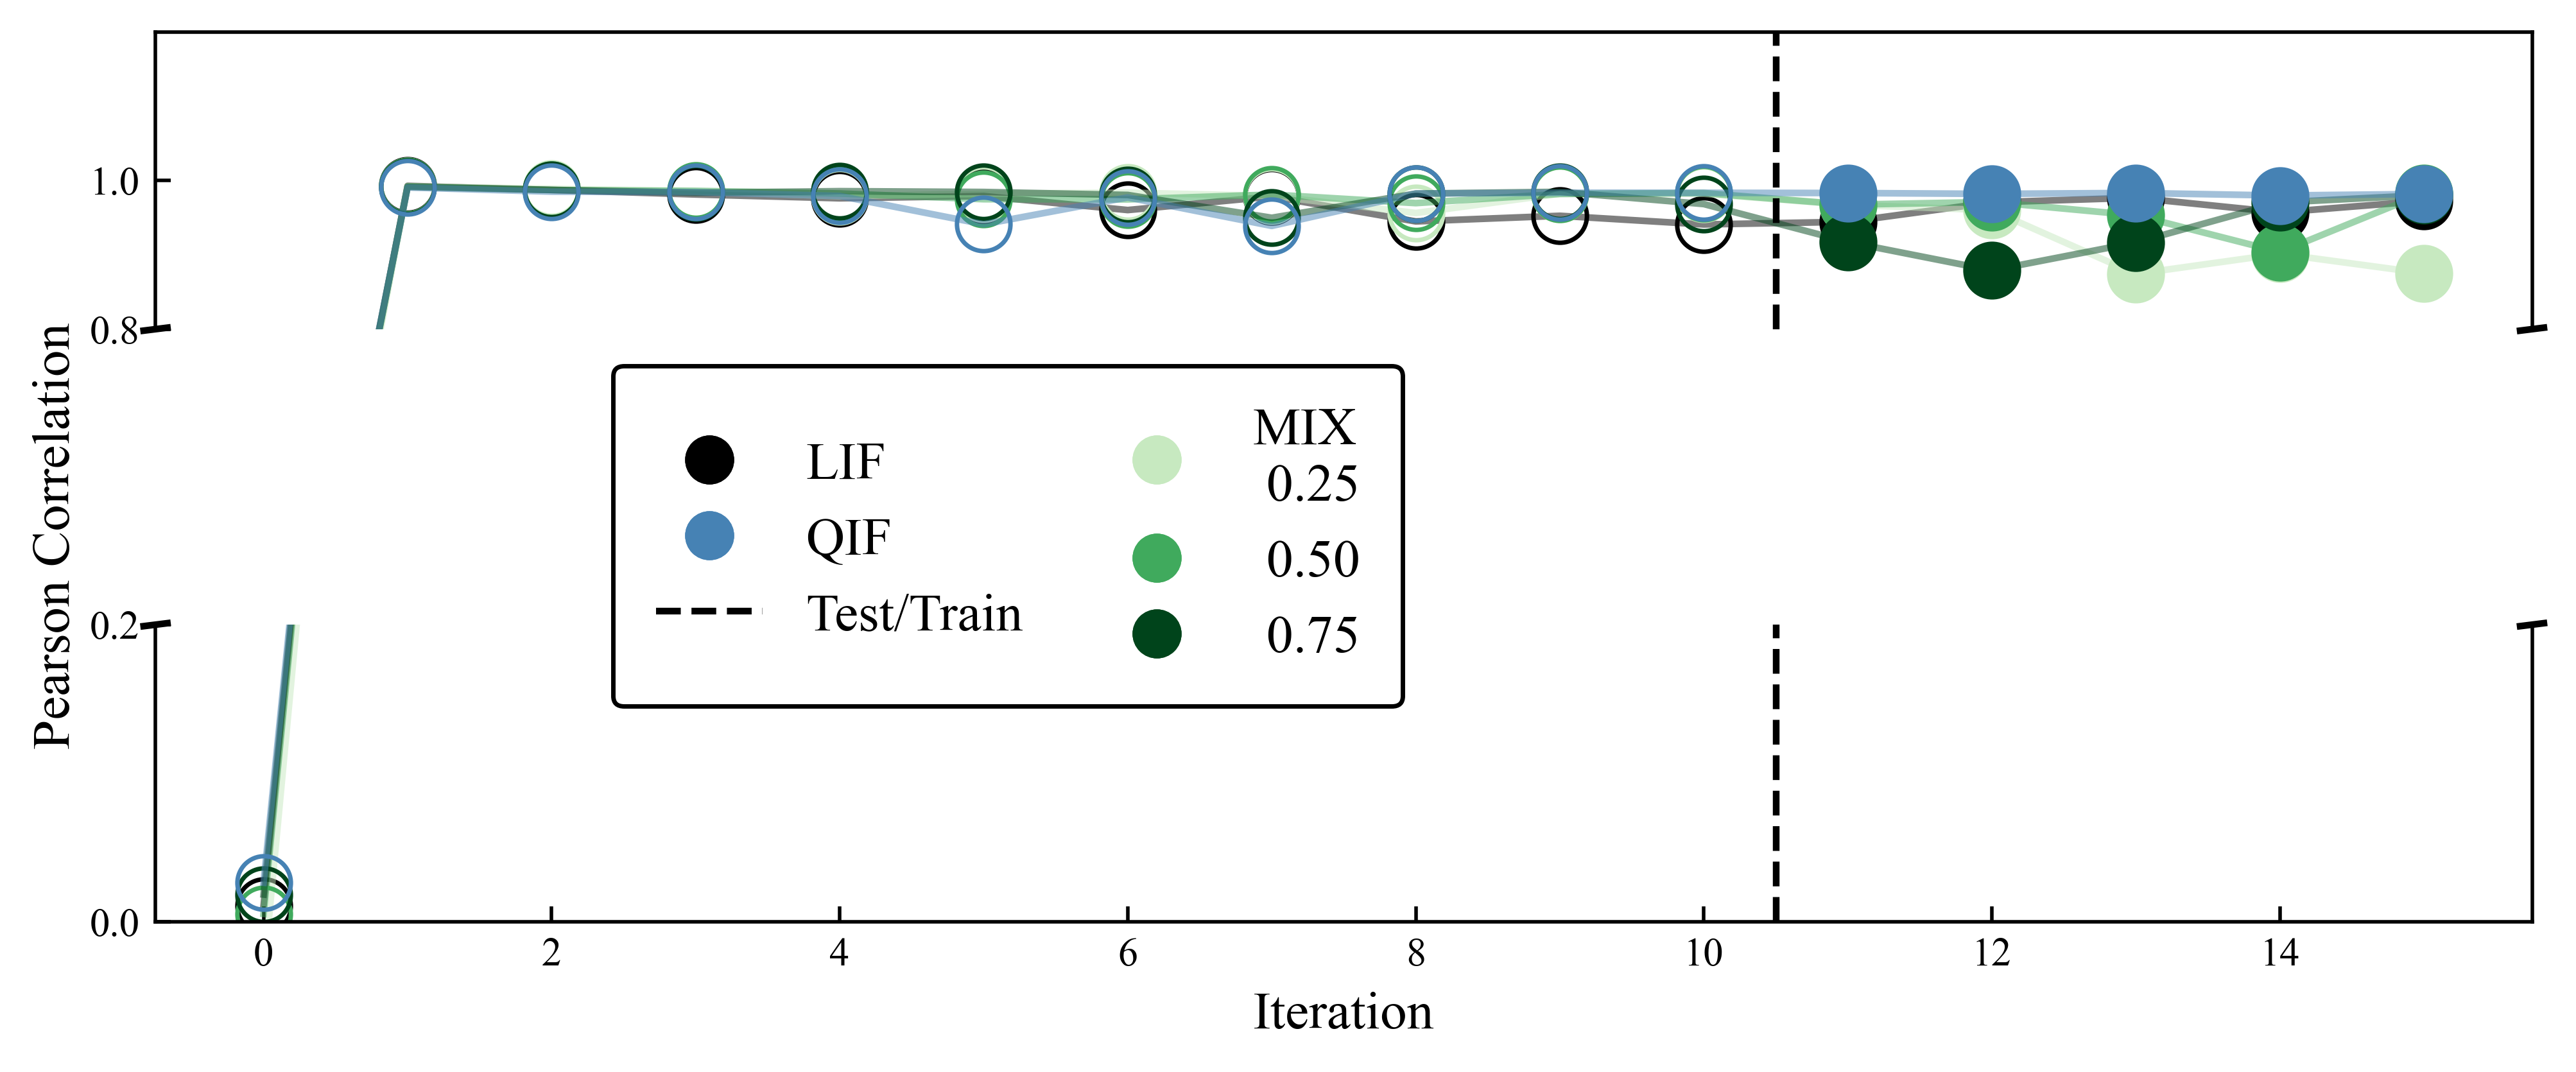

In [14]:
# ========== Correlation WITH BROKEN AXIS ==========

# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(9,13)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", f"MIX\n 0.25", " 0.50", " 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 9
itmax = 1000
itstim = 200 
nloop = 16

yticks_top = [0.80, 1]
yticks_bottom = [0, 0.2]


# Create figure
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 
    1, 
    sharex=True, 
    figsize=(8,3.5)
    )
figname = f"sequences_correlation"

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(f'sequences/simulation_{idx}/simulation_{idx}_targets_{pq}.csv')
        targets = target_csv.values

        file = f'sequences/simulation_{idx}/simulation_{idx}_inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_0.csv'  # load input
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers ON BOTH AXES
    ax_top.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_top.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_top.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_top.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

    ax_bottom.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax_bottom.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax_bottom.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax_bottom.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')

# Break y axis
ax_top.set_ylim(0.80, 1.2)  # Upper range
ax_bottom.set_ylim(0, 0.2)  # Lower range

ax_top.set_yticks(yticks_top)
ax_bottom.set_yticks(yticks_bottom)

# Hide spines between axes

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

# Disable ticks where break is
ax_top.tick_params(labeltop=False, bottom=False),
ax_bottom.tick_params(top=False)

# Diagonal break marks
d = 0.005 # size of diagonal lines in axes coordinate
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels and scales
# ax_top.set_title('Sequences')
ax_top.axvline(10.5, color='black', linestyle="--")
ax_bottom.axvline(10.5, color='black', linestyle="--")
ax_bottom.set_xlabel('Iteration')
# ax_top.set_ylabel('Pearson Correlation')
# ax_top.set_ylabel('$r$')
fig.text(
    0, 
    0.5, 
    "Pearson Correlation", 
    va='center', 
    rotation='vertical',
    fontsize=plt.rcParams['axes.labelsize']
    )

# Optional: custom legend
legend_elements = []
labels = []

names = ["LIF", "QIF", f"MIX\n 0.25", " 0.50", " 0.75"]
pqif_values = [0, 1, 0.25, 0.50, 0.75]

for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}")

vertical_line = Line2D([0], [0], color='black', linestyle='--')
# legend_elements.append(vertical_line)
# labels.append(f"Test/Train")
legend_elements.insert(2, vertical_line)
labels.insert(2, f"Test/Train")


# ax_bottom.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')
ax_bottom.legend(
    legend_elements,
    labels,
    handler_map={tuple: HandlerTuple()},
    ncol=2,                             # number of columns
    loc='center',                       # anchor point
    bbox_to_anchor=(0.38, 0.5),          # center of axes or figure depending on next line
    bbox_transform=fig.transFigure,     # figure coordinates
    frameon=True,                       # rectangular legend box
    edgecolor='black',
    framealpha=1.0,
    # borderpad=1.2,
    borderpad=0.8,
    columnspacing=1.5,
    handletextpad=0.8
)

plt.tight_layout()
# plt.savefig(os.path.join(figure_folder, figname))
full_path = os.path.join(figure_folder, figname)
plt.savefig(full_path, format="svg")
plt.show()